# Dataset Acquisition

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import sklearn

github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_git = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_git.head())
    print(df_git.shape[0])
except Exception as e:
    print(f"Error during loading from github: {e}")


Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


In [11]:

target_col = "Status"
id_col = "ID" if "ID" in df_git.columns else None

print("SHAPE:", df_git.shape)
print("\nTARGET distribution:")
print(df_git[target_col].value_counts(dropna=False))

print("\nEXACT DUPLICATE ROWS:", df_git.duplicated().sum())

if id_col is not None:
    print("\nID check:")
    print("Unique IDs:", df_git[id_col].nunique(dropna=False))
    print("Repeated ID values:", (df_git[id_col].value_counts(dropna=False) > 1).sum())
    print("Rows with repeated ID:", df_git[id_col].duplicated().sum())

    # Se ID è un vero gruppo, ci devono essere più righe per lo stesso ID
    # e idealmente più target per lo stesso ID può essere un segnale di dipendenza
    id_target = df_git.groupby(id_col)[target_col].nunique(dropna=False)
    print("\nIDs with more than one target value:", (id_target > 1).sum())



SHAPE: (148670, 34)

TARGET distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

EXACT DUPLICATE ROWS: 0

ID check:
Unique IDs: 148670
Repeated ID values: 0
Rows with repeated ID: 0

IDs with more than one target value: 0


# Preprocessing

In [12]:
# REMOVAL OF FEATURES
df = df_git.copy()

columns_to_drop = ['Upfront_charges', 'rate_of_interest', 'Interest_rate_spread'
                  , 'property_value', 'LTV', 'ID', 'year', "credit_type"]

for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

# INSERTING UNKNOWN CLASS IN LOAN LIMIT
df['loan_limit'] = df['loan_limit'].fillna('Non_definito')
print("Loan limit after the operation")
print(df['loan_limit'].value_counts(dropna=False))

#REMOVAL OF RECORDS WITH NULL VALUES
interested_features = ['age', 'submission_of_application', 'loan_purpose', 'Neg_ammortization', 'term']
rows = df.shape[0]

for feat in interested_features:
    if feat in df.columns:
        df.dropna(subset=[feat], inplace=True)
        print(f"Rows dropped for {feat}: {rows - df.shape[0]}")
        rows = df.shape[0]
    else:
        print(f"Column '{feat}' not found. Skipping operation.")

# CHECK FOR DUPLICATE ROWS
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df[df.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

#REDUNDANCIES ADDRESSING
columns_to_remove = ['construction_type', 'Security_Type']

for col in columns_to_remove:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Column '{col}' removed successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Mostra solo le colonne che hanno almeno 1 NaN
print(missing_df[missing_df['Missing Values'] > 0])

Column 'Upfront_charges' dropped successfully.
Column 'rate_of_interest' dropped successfully.
Column 'Interest_rate_spread' dropped successfully.
Column 'property_value' dropped successfully.
Column 'LTV' dropped successfully.
Column 'ID' dropped successfully.
Column 'year' dropped successfully.
Column 'credit_type' dropped successfully.
Loan limit after the operation
loan_limit
cf              135348
ncf               9978
Non_definito      3344
Name: count, dtype: int64
Rows dropped for age: 200
Rows dropped for submission_of_application: 0
Rows dropped for loan_purpose: 126
Rows dropped for Neg_ammortization: 121
Rows dropped for term: 41
Number of duplicate rows found: 12
Column 'construction_type' removed successfully.
Column 'Security_Type' removed successfully.
               Missing Values  Missing %
dtir1                   23883      16.12
income                   8949       6.04
approv_in_adv             908       0.61


# Classification

## Common setup

In [13]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

d = df.copy()
# --- feature / target ---
X = d.drop(columns=["Status"])
y = d["Status"]

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", num_features)
print("Categorical:", cat_features)

# --- preprocessore colonna per colonna ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   #median imputation
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  #mode imputation
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)


Numerical: ['loan_amount', 'term', 'income', 'Credit_Score', 'dtir1']
Categorical: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region']


In [51]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix
)

SEED = 42
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def build_local_grid(best_params, model_name):
    if model_name == "LogReg":
        c = best_params["clf__C"]
        return {
            "clf__C": np.logspace(np.log10(c/5), np.log10(c*5), 5),
            "clf__class_weight": [best_params["clf__class_weight"]],
            "clf__solver": [best_params["clf__solver"]],
            "clf__max_iter": [best_params["clf__max_iter"]],
            "clf__penalty": ["l2"]
        }

    if model_name == "DecTree":
        d = best_params["clf__max_depth"]
        m = best_params["clf__min_samples_leaf"]
        return {
            "clf__max_depth": [None] if d is None else sorted(list(set([max(1, d-2), d, d+2]))),
            "clf__min_samples_leaf": sorted(list(set([max(1, m-5), m, m+5]))),
            "clf__criterion": [best_params["clf__criterion"]],
            "clf__class_weight": [best_params["clf__class_weight"]]
        }

    if model_name == "RandFor":
        n = best_params["clf__n_estimators"]
        d = best_params["clf__max_depth"]
        m = best_params["clf__min_samples_leaf"]
        return {
            "clf__n_estimators": sorted(list(set([max(30, n-20), n, n+20]))),
            "clf__max_depth": [d] if d is None else sorted(list(set([max(2, d-2), d, d+2]))),
            "clf__min_samples_leaf": sorted(list(set([max(1, m-5), m, m+5]))),
            "clf__class_weight": [best_params["clf__class_weight"]],
            "clf__max_features": [best_params["clf__max_features"]]
        }

    if model_name == "AdaBoost":
        n = best_params["clf__n_estimators"]
        lr = best_params["clf__learning_rate"]
        return {
            "clf__n_estimators": sorted(list(set([max(20, n-20), n, n+20]))),
            "clf__learning_rate": np.logspace(np.log10(lr/3), np.log10(lr*3), 5)
        }

    if model_name == "NaiveBayes":
        return{}

    if model_name == "GradBoost":
        n = best_params["clf__n_estimators"]
        lr = best_params["clf__learning_rate"]
        d = best_params["clf__max_depth"]
        m = best_params["clf__min_samples_leaf"]
        return {
            "clf__n_estimators": sorted(list(set([max(50, n-50), n, n+50]))),
            "clf__learning_rate": np.logspace(np.log10(lr/3), np.log10(lr*3), 5),
            "clf__max_depth": sorted(list(set([max(1, d-1), d, d+1]))),
            "clf__min_samples_leaf": sorted(list(set([max(1, m-5), m, m+5]))),
            "clf__subsample": [best_params["clf__subsample"]],
            "clf__max_features": [best_params["clf__max_features"]]
        }

    raise ValueError("Model not supported")

def nested_cv(pipeline, random_space, model_name, X, y, n_iter=20, scoring="roc_auc"):
    fold_rows = []
    oof_pred = np.zeros(len(y))
    oof_proba = np.zeros(len(y), dtype=float)

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        rs = RandomizedSearchCV(
            pipeline,
            param_distributions=random_space,
            n_iter=n_iter,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=1,
            random_state=SEED,
            refit=True
        )
        rs.fit(X_tr, y_tr)

        local_grid = build_local_grid(rs.best_params_, model_name)
        gs = GridSearchCV(
            pipeline,
            param_grid=local_grid,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=1,
            refit=True
        )
        gs.fit(X_tr, y_tr)
        best_model = gs.best_estimator_
        
        y_pred = best_model.predict(X_te)
        y_score = best_model.predict_proba(X_te)[:, 1]

        oof_pred[te_idx] = y_pred
        oof_proba[te_idx] = y_score

        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        fold_rows.append({
            "model": model_name,
            "fold": fold,
            "auc": roc_auc_score(y_te, y_score),
            "f1": f1_score(y_te, y_pred),
            "precision": precision_score(y_te, y_pred, zero_division=0),
            "recall": recall_score(y_te, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
            "fpr": fp / (fp + tn) if (fp + tn) else 0.0,
            "fnr": fn / (fn + tp) if (fn + tp) else 0.0,
            "rs_best_params": rs.best_params_,
            "gs_best_params": gs.best_params_
        })

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "model": model_name,
        "auc_mean": fold_df["auc"].mean(),
        "auc_std": fold_df["auc"].std(),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),
        "precision_mean": fold_df["precision"].mean(),
        "precision_std": fold_df["precision"].std(),
        "recall_mean": fold_df["recall"].mean(),
        "recall_std": fold_df["recall"].std(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "fpr_mean": fold_df["fpr"].mean(),
        "fnr_mean": fold_df["fnr"].mean()
    }

    return {
        "summary": summary, 
        "folds": fold_df,
        "oof_pred": oof_pred, 
        "oof_proba": oof_proba
    }

Perché ROC_AUC: È lo standard industriale per la selezione dei parametri perché è robusto allo sbilanciamento e misura la capacità di separazione

In [55]:
from sklearn.metrics import confusion_matrix
def clean_params(params):
    return {
        k: v.item() if isinstance(v, np.generic) else v
        for k, v in params.items()
    }

from sklearn.metrics import confusion_matrix
import pandas as pd

def print_model_report(model_name, summary, folds, y_true, oof_pred, param_col="gs_best_params"):
    print("=" * 60)
    print(f"{model_name.upper()} - NESTED CV")
    print("=" * 60)

    print(f"AUC:      {summary['auc_mean']:.3f} ± {summary['auc_std']:.3f}")
    print(f"F1:       {summary['f1_mean']:.3f} ± {summary['f1_std']:.3f}")
    print(f"Precision:{summary['precision_mean']:.3f} ± {summary['precision_std']:.3f}")
    print(f"Recall:   {summary['recall_mean']:.3f} ± {summary['recall_std']:.3f}")
    print(f"BAcc:     {summary['balanced_accuracy_mean']:.3f} ± {summary['balanced_accuracy_std']:.3f}")
    print(f"FPR mean: {summary['fpr_mean']:.3f}")
    print(f"FNR mean: {summary['fnr_mean']:.3f}")


    print("\nFold metrics:")
    display(folds[[
        "fold", "auc", "f1", "precision", "recall",
        "balanced_accuracy", "fpr", "fnr"
    ]].round(3))

    # Single-fold parameters print
    # if param_col in folds.columns:
    #     param_strings = folds[param_col].astype(str)
    #     if param_strings.nunique() == 1:
    #         print("\nBest params:")
    #         print(clean_params(folds[param_col].iloc[0]))
    #     else:
    #         print("\nBest params per fold:")
    #         display(folds[["fold", param_col]])

    cm = confusion_matrix(y_true, oof_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion matrix OOF:")
    print(f"TN={tn} | FP={fp}")
    print(f"FN={fn} | TP={tp}")
    print(f"FPR={fp / (fp + tn):.3f} | FNR={fn / (fn + tp):.3f}")
    print("=" * 60)

## Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform

pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(random_state=SEED))
])

random_space_lr = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "newton-cg", "saga", "liblinear"],
    "clf__max_iter": [2000, 5000, 10000]
}

lr_results = nested_cv(
    pipe_lr, random_space_lr, "LogReg", X, y, n_iter=30
)

In [56]:
print_model_report(
    model_name="LogReg",
    summary=lr_results["summary"],
    folds=lr_results["folds"],
    y_true=y,
    oof_pred=lr_results["oof_pred"],
    param_col="gs_best_params"
)

LOGREG - NESTED CV
AUC:      0.737 ± 0.002
F1:       0.509 ± 0.003
Precision:0.429 ± 0.004
Recall:   0.626 ± 0.006
BAcc:     0.677 ± 0.003
FPR mean: 0.271
FNR mean: 0.374

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.740,0.511,0.432,0.626,0.679,0.268,0.374
1,2,0.735,0.513,0.430,0.634,0.681,0.273,0.366
2,3,0.740,0.509,0.429,0.625,0.677,0.271,0.375
3,4,0.734,0.508,0.431,0.617,0.676,0.265,0.383
4,5,0.736,0.504,0.422,0.626,0.674,0.278,0.374



Confusion matrix OOF:
TN=81522 | FP=30295
FN=13610 | TP=22755
FPR=0.271 | FNR=0.374


## Naive Bayes

Skeweness analysis

In [18]:
import matplotlib.pyplot as plt

print(X[num_features].skew().sort_values(ascending=False))

desc = X[num_features].describe().T[["mean", "50%"]]  # 50% = median
desc["mean_minus_median"] = desc["mean"] - desc["50%"]
print(desc.sort_values("mean_minus_median"))

income          17.333268
loan_amount      1.664427
Credit_Score     0.004948
dtir1           -0.551419
term            -2.172949
dtype: float64
                       mean       50%  mean_minus_median
term             335.120048     360.0         -24.879952
dtir1             37.732604      39.0          -1.267396
Credit_Score     699.766375     699.0           0.766375
income          6956.480145    5760.0        1196.480145
loan_amount   331287.558543  296500.0       34787.558543


In [19]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

# sposto 'term' da numerica a categorica (se presente)
if "term" in num_features:
    num_features.remove("term")
    if "term" not in cat_features:
        cat_features.append("term")

# variabili numeriche molto skewed
num_skewed = ["income", "loan_amount"]
num_skewed = [c for c in num_skewed if c in num_features]

# il resto delle numeriche
num_normal = [c for c in num_features if c not in num_skewed]

print("Num skewed:", num_skewed)
print("Num normal:", num_normal)
print("Cat (with term):", cat_features)

# per le numeriche skewed: mediana -> log1p -> scaler
numeric_skewed_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

# per le altre numeriche: riuso il transformer generale
numeric_normal_transformer = numeric_transformer   # mediana + StandardScaler

# categoriche: MODIFICA PER GNB - OneHotEncoder deve produrre output denso
categorical_nb_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_nb = ColumnTransformer(
    transformers=[
        ("num_skewed", numeric_skewed_transformer, num_skewed),
        ("num_normal", numeric_normal_transformer, num_normal),
        ("cat",        categorical_nb_transformer, cat_features),
    ]
)

pipe_nb = Pipeline(steps=[
    ("preprocess", preprocess_nb),
    ("clf", GaussianNB())
])

random_space_nb = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_results = nested_cv(
    pipe_nb, {}, "NaiveBayes", X, y, n_iter=5
)


Num skewed: ['income', 'loan_amount']
Num normal: ['Credit_Score', 'dtir1']
Cat (with term): ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'term']


In [57]:
print_model_report(
    model_name="NaiveBayes",
    summary=nb_results["summary"],
    folds=nb_results["folds"],
    y_true=y,
    oof_pred=nb_results["oof_pred"],
    param_col="gs_best_params"
)

NAIVEBAYES - NESTED CV
AUC:      0.682 ± 0.004
F1:       0.324 ± 0.058
Precision:0.549 ± 0.069
Recall:   0.241 ± 0.078
BAcc:     0.585 ± 0.018
FPR mean: 0.071
FNR mean: 0.759

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.684,0.269,0.613,0.172,0.568,0.035,0.828
1,2,0.676,0.276,0.599,0.180,0.570,0.039,0.820
2,3,0.685,0.391,0.479,0.330,0.607,0.117,0.670
3,4,0.680,0.382,0.471,0.322,0.602,0.118,0.678
4,5,0.684,0.302,0.584,0.203,0.578,0.047,0.797



Confusion matrix OOF:
TN=103849 | FP=7968
FN=27587 | TP=8778
FPR=0.071 | FNR=0.759


## Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

#PIPELINE PREPROCESS + CLASSIFIER
pipe_dt = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

#PARAMS
random_space_dt = {
    "clf__max_depth":        [3, 5, 8, 10, 15, None],
    "clf__min_samples_leaf": [1, 5, 10, 20, 50],
    "clf__criterion":        ["gini", "entropy"],
    "clf__class_weight":     [None, "balanced"],
}

dt_results = nested_cv(
    pipe_dt, random_space_dt, "DecTree", X, y, n_iter=30
)


In [58]:
print_model_report(
    model_name="DecTree",
    summary=dt_results["summary"],
    folds=dt_results["folds"],
    y_true=y,
    oof_pred=dt_results["oof_pred"],
    param_col="gs_best_params"
)

DECTREE - NESTED CV
AUC:      0.856 ± 0.003
F1:       0.673 ± 0.004
Precision:0.668 ± 0.009
Recall:   0.679 ± 0.002
BAcc:     0.785 ± 0.002
FPR mean: 0.110
FNR mean: 0.321

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.860,0.677,0.678,0.677,0.786,0.105,0.323
1,2,0.855,0.678,0.674,0.682,0.787,0.107,0.318
2,3,0.853,0.668,0.659,0.677,0.782,0.114,0.323
3,4,0.856,0.670,0.658,0.682,0.783,0.115,0.318
4,5,0.854,0.674,0.670,0.679,0.785,0.109,0.321



Confusion matrix OOF:
TN=99510 | FP=12307
FN=11662 | TP=24703
FPR=0.110 | FNR=0.321


## Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        random_state=SEED
    ))
])

random_space_rf = {
    "clf__n_estimators":     [50, 100],
    "clf__max_depth":        [10, None],
    "clf__min_samples_leaf": [10, 20],
    "clf__max_features":     ["sqrt", "log2", 0.3],
    "clf__class_weight":     [None, "balanced"],
}

rf_results = nested_cv(
    pipe_rf, random_space_rf, "RandFor", X, y, n_iter=15
)

In [60]:
print_model_report(
    model_name="RandFor",
    summary=rf_results["summary"],
    folds=rf_results["folds"],
    y_true=y,
    oof_pred=rf_results["oof_pred"],
    param_col="gs_best_params"
)

RANDFOR - NESTED CV
AUC:      0.866 ± 0.002
F1:       0.692 ± 0.003
Precision:0.709 ± 0.006
Recall:   0.675 ± 0.004
BAcc:     0.792 ± 0.002
FPR mean: 0.090
FNR mean: 0.325

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.869,0.696,0.718,0.675,0.794,0.086,0.325
1,2,0.865,0.692,0.707,0.677,0.793,0.091,0.323
2,3,0.865,0.688,0.708,0.669,0.790,0.090,0.331
3,4,0.864,0.692,0.710,0.675,0.793,0.090,0.325
4,5,0.866,0.690,0.701,0.679,0.793,0.094,0.321



Confusion matrix OOF:
TN=101727 | FP=10090
FN=11815 | TP=24550
FPR=0.090 | FNR=0.325


## AdaBoost

In [27]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

pipe_ada = Pipeline([
    ("preprocess", preprocess),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
        random_state=SEED
    ))
])

random_space_ada = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

ada_results = nested_cv(
    pipe_ada, random_space_ada, "AdaBoost", X, y, n_iter=10
)

In [28]:
print_model_report(
    model_name="AdaBoost",
    summary=ada_results["summary"],
    folds=ada_results["folds"],
    y_true=y,
    oof_pred=ada_results["oof_pred"],
    param_col="gs_best_params"
)

ADABOOST - NESTED CV
AUC:      0.831 ± 0.003
F1:       0.619 ± 0.006
Precision:0.773 ± 0.007
Recall:   0.516 ± 0.008
BAcc:     0.734 ± 0.003
FPR mean: 0.049
FNR mean: 0.484

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.835,0.620,0.775,0.516,0.734,0.049,0.484
1,2,0.829,0.620,0.764,0.521,0.734,0.052,0.479
2,3,0.830,0.610,0.772,0.505,0.728,0.049,0.495
3,4,0.829,0.620,0.783,0.514,0.734,0.046,0.486
4,5,0.834,0.626,0.772,0.526,0.738,0.050,0.474



Best params per fold:


,fold,gs_best_params
0,1,"{'clf__learning_rate': 1.7320508075688774, 'cl..."
1,2,"{'clf__learning_rate': 1.7320508075688774, 'cl..."
2,3,"{'clf__learning_rate': 1.7320508075688774, 'cl..."
3,4,"{'clf__learning_rate': 1.7320508075688774, 'cl..."
4,5,"{'clf__learning_rate': 1.7320508075688774, 'cl..."



Confusion matrix OOF:
TN=106309 | FP=5508
FN=17584 | TP=18781
FPR=0.049 | FNR=0.484


## Gradient Boost

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", GradientBoostingClassifier(random_state=SEED))
])

random_space_gb = {
    "clf__n_estimators":   [100, 200, 300],
    "clf__learning_rate":  [0.01, 0.05, 0.1],
    "clf__max_depth":      [2, 3, 4],
    "clf__min_samples_leaf": [20, 50, 100],
    "clf__subsample":      [0.6, 0.8, 1.0],
    "clf__max_features":   ["sqrt", "log2", None],
}

gb_results = nested_cv(
    pipe_gb, random_space_gb, "GradBoost", X, y, n_iter=10
)


In [30]:
print_model_report(
    model_name="GradBoost",
    summary=gb_results["summary"],
    folds=gb_results["folds"],
    y_true=y,
    oof_pred=gb_results["oof_pred"],
    param_col="gs_best_params"
)

GRADBOOST - NESTED CV
AUC:      0.871 ± 0.002
F1:       0.699 ± 0.005
Precision:0.859 ± 0.006
Recall:   0.589 ± 0.006
BAcc:     0.779 ± 0.003
FPR mean: 0.031
FNR mean: 0.411

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.874,0.701,0.864,0.590,0.780,0.030,0.410
1,2,0.870,0.699,0.854,0.592,0.780,0.033,0.408
2,3,0.870,0.692,0.852,0.583,0.775,0.033,0.417
3,4,0.871,0.696,0.864,0.583,0.777,0.030,0.417
4,5,0.872,0.705,0.861,0.597,0.783,0.031,0.403



Best params per fold:


,fold,gs_best_params
0,1,"{'clf__learning_rate': 0.08660254037844387, 'c..."
1,2,"{'clf__learning_rate': 0.15000000000000005, 'c..."
2,3,"{'clf__learning_rate': 0.15000000000000005, 'c..."
3,4,"{'clf__learning_rate': 0.08660254037844387, 'c..."
4,5,"{'clf__learning_rate': 0.08660254037844387, 'c..."



Confusion matrix OOF:
TN=108299 | FP=3518
FN=14945 | TP=21420
FPR=0.031 | FNR=0.411


# Comparison

In [61]:
import matplotlib.pyplot as plt

results = [
    lr_results["summary"],
    dt_results["summary"],
    nb_results["summary"],
    rf_results["summary"],
    ada_results["summary"],
    gb_results["summary"]
]

results_df = pd.DataFrame(results)

results_df = results_df[[
    "model",
    "f1_mean", "f1_std",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "precision_mean", "recall_mean",
    "auc_mean", "auc_std",
    "fpr_mean", "fnr_mean"
]].sort_values(by=["balanced_accuracy_mean", "recall_mean", "f1_mean"],
                 ascending=False)
# qui da decidere meglio il criterio di scelta e giustificarlo
# magari mettere una soglia minima di recall e poi predere il modello con 
# bal_acc più alta
# Questa logica evita il caso patologico del modello con recall altissimo ma performance complessiva pessima, e allo stesso tempo mantiene il focus sul rischio di perdere i default. In credit risk, infatti, il richiamo dei casi positivi è importante, ma non a costo di distruggere la capacità del modello di distinguere bene le classi in generale.
# in questo modo prendimao il modello con il minor numero di falsi negativi , il cui rischio è più alto dei falsi positivi:
# Questa logica evita il caso patologico del modello con recall altissimo ma performance complessiva pessima, e allo stesso tempo mantiene il focus sul rischio di perdere i default. In credit risk, infatti, il richiamo dei casi positivi è importante, ma non a costo di distruggere la capacità del modello di distinguere bene le classi in generale.
# allo stesso tempo, La balanced accuracy è una metrica adatta ai dataset sbilanciati perché media il recall delle classi, quindi evita che il modello vinca solo grazie alla classe maggioritaria

display(results_df)

,model,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,recall_mean,auc_mean,auc_std,fpr_mean,fnr_mean
3,RandFor,0.691505,0.002953,0.792431,0.001793,0.708766,0.675100,0.865574,0.001837,0.090237,0.324900
1,DecTree,0.673359,0.004405,0.784622,0.002201,0.667571,0.679307,0.855509,0.002642,0.110064,0.320693
5,GradBoost,0.698815,0.004823,0.778783,0.003001,0.858954,0.589028,0.871372,0.001957,0.031462,0.410972
4,AdaBoost,0.619259,0.005569,0.733600,0.003478,0.773299,0.516458,0.831299,0.002741,0.049259,0.483542
0,LogReg,0.508978,0.003279,0.677403,0.002677,0.428965,0.625739,0.736981,0.002407,0.270934,0.374261
2,NaiveBayes,0.323932,0.058440,0.585063,0.018009,0.548902,0.241386,0.681715,0.003547,0.071260,0.758614


commento

## Performance stability across folds

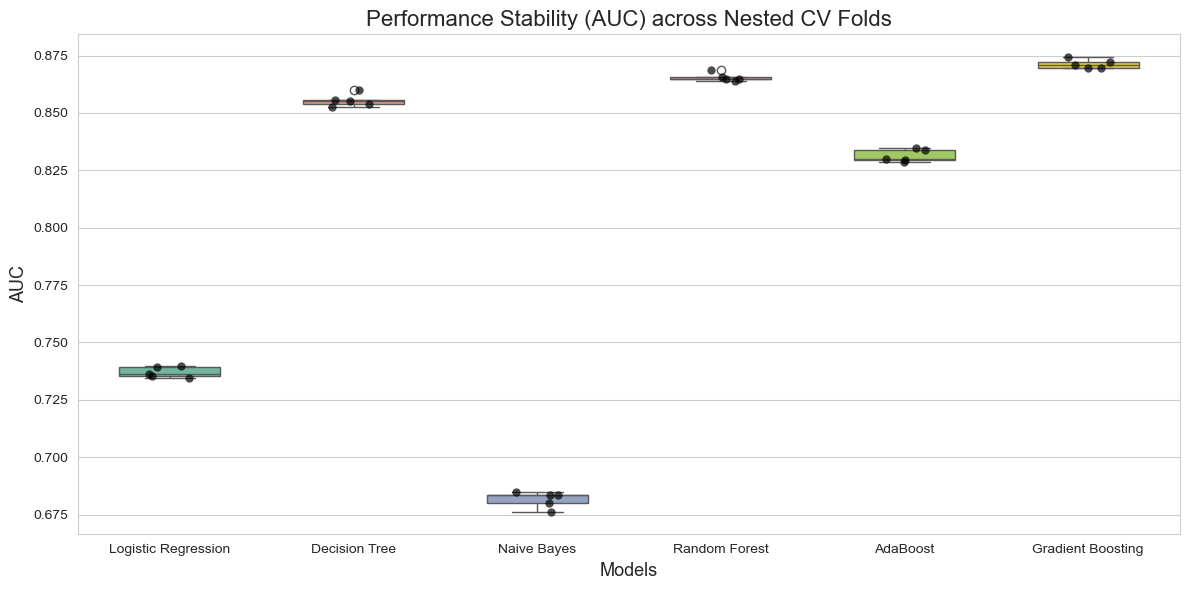

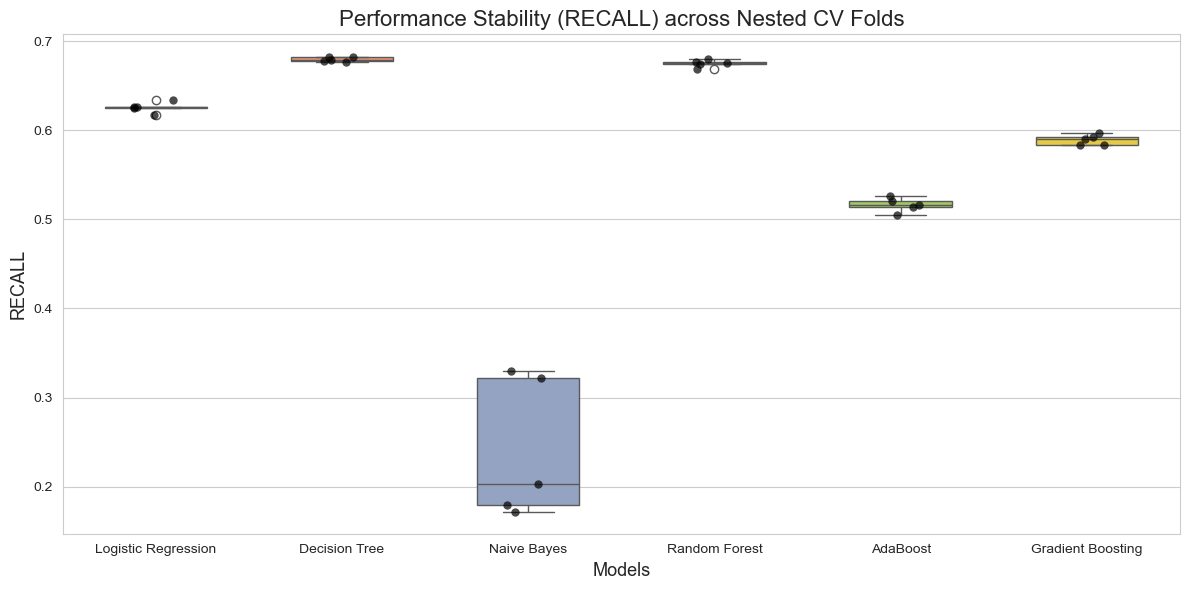

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_dict = {
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Naive Bayes": nb_results,
    "Random Forest": rf_results,
    "AdaBoost": ada_results,
    "Gradient Boosting": gb_results
}

#da scegliere la metrica
def plot_nestedcv_stability(results_dict, metric="auc"):
    dfs = []
    for model_name, res in results_dict.items():
        df = res["folds"].copy()
        if metric not in df.columns:
            raise ValueError(f"Metric '{metric}' not found in folds dataframe.")
        df["model"] = model_name
        dfs.append(df)

    plot_df = pd.concat(dfs, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    order = list(results_dict.keys())

    ax = sns.boxplot(
        data=plot_df,
        x="model",
        y=metric,
        hue="model",
        order=order,
        palette="Set2",
        width=0.55,
        showfliers=True,
        legend=False
    )

    sns.stripplot(
        data=plot_df,
        x="model",
        y=metric,
        order=order,
        color="black",
        size=6,
        jitter=0.12,
        alpha=0.7
    )

    ax.set_title(f"Performance Stability ({metric.upper()}) across Nested CV Folds", fontsize=16)
    ax.set_xlabel("Models", fontsize=13)
    ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=13)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_nestedcv_stability(results_dict, metric="auc")
plot_nestedcv_stability(results_dict, metric="recall")

Nel confronto tra i modelli, la Random Forest emerge come la soluzione più equilibrata per il problema di classificazione default/non-default. La nested cross-validation mostra infatti non solo una performance media elevata, ma anche una variabilità molto contenuta tra i fold, segnale di performance stability e quindi di robustezza rispetto a diverse partizioni del campione. In un contesto bancario questo aspetto è decisivo, perché un modello credibile non deve soltanto performare bene in media, ma deve restare consistente quando viene applicato a portafogli nuovi e leggermente diversi da quelli di addestramento.

La Random Forest è particolarmente adatta a questo scenario perché riesce a catturare relazioni non lineari e interazioni complesse tra le variabili, senza richiedere ipotesi forti sulla forma del legame tra rischio e feature. Allo stesso tempo, il comportamento osservato nei fold è regolare, quindi il modello non mostra oscillazioni marcate né segnali di instabilità che farebbero dubitare della sua generalizzazione. Per questo motivo, la combinazione di AUC elevata, recall stabile e bassa dispersione rende la Random Forest una scelta solida per il credit scoring.

Decision Tree ha una migliore Recall ma pecca in AUC, mentre GradBoost ha un migliore AUC ma pecca in Recall. Random forest ottimo compromesso

## Final model choice

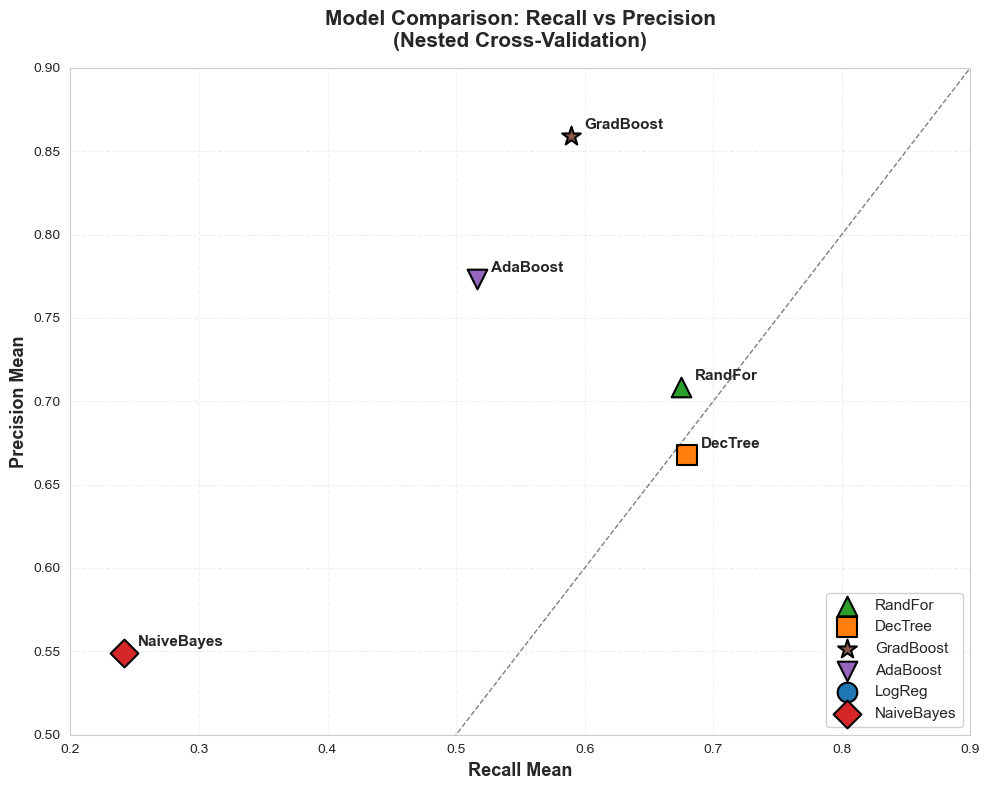


 Modello migliore per metriche grafico: RandFor
   Recall: 0.6751
   Precision: 0.7088


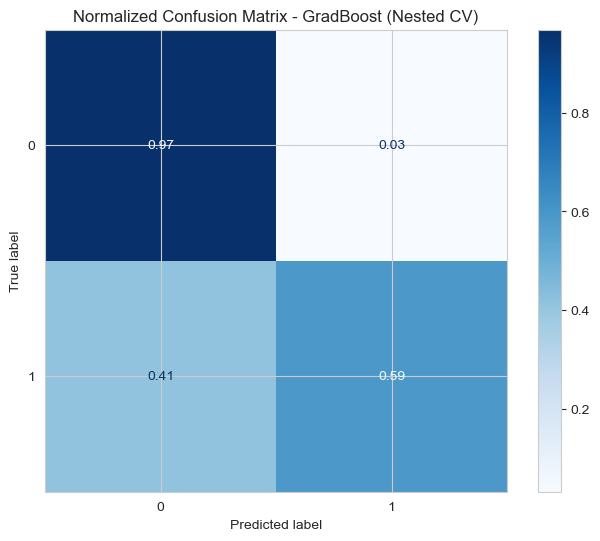

In [80]:
# Creare il grafico Recall_mean vs precision_mean
fig, ax = plt.subplots(figsize=(10, 8))

# Colori per ogni modello
colors = {
    "LogReg": "#1f77b4",      # blu
    "DecTree": "#ff7f0e",     # arancione
    "RandFor": "#2ca02c",     # verde
    "NaiveBayes": "#d62728",  # rosso
    "AdaBoost": "#9467bd",    # viola
    "GradBoost": "#8c564b"      # marrone
}

# Marker per ogni modello
markers = {
    "LogReg": "o",
    "DecTree": "s",
    "RandFor": "^",
    "NaiveBayes": "D",
    "AdaBoost": "v",
    "GradBoost": "*"
}

# Plot punto per modello
for idx, row in results_df.iterrows():
    model = row["model"]
    ax.scatter(
        row["recall_mean"], 
        row["precision_mean"],
        color=colors.get(model, "gray"),
        marker=markers.get(model, "o"),
        s=200,
        label=model,
        edgecolors="black",
        linewidths=1.5
    )
    
    # Aggiungere etichette testo vicino ai punti
    ax.annotate(
        model,
        (row["recall_mean"], row["precision_mean"]),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=11,
        fontweight="bold"
    )

# Configurazioni grafico
ax.set_xlabel("Recall Mean", fontsize=13, fontweight="bold")
ax.set_ylabel("Precision Mean", fontsize=13, fontweight="bold")
ax.set_title("Model Comparison: Recall vs Precision\n(Nested Cross-Validation)", fontsize=15, fontweight="bold", pad=15)

ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)

# Impostare limiti assi per meglio visualizzare i punti
ax.set_xlim(0.2, 0.9)
ax.set_ylim(0.5, 0.9)

# Aggiungere linea di riferimento 45° (recall = bal_acc)
x_vals = [0, 1.0]
ax.plot(x_vals, x_vals, "k--", alpha=0.5, linewidth=1, label="Reference (recall = bal_acc)")

plt.tight_layout()
plt.show()

# Evidenziare il modello migliore
best_model = results_df.iloc[0]["model"]
print(f"\n Modello migliore per metriche grafico: {best_model}")
print(f"   Recall: {results_df.iloc[0]['recall_mean']:.4f}")
print(f"   Precision: {results_df.iloc[0]['precision_mean']:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = results_df.iloc[0]["model"]

if best_model_name == "LogReg":
    y_pred = lr_results["oof_pred"]
elif best_model_name == "DecTree":
    y_pred = dt_results["oof_pred"]
elif best_model_name == "RandFor":
    y_pred = rf_results["oof_pred"]
elif best_model_name == "NaiveBayes":
    y_pred = nb_results["oof_pred"]
elif best_model_name == "AdaBoost":
    y_pred = ada_results["oof_pred"]
elif best_model_name == "GradBoost":
    y_pred = gb_results["oof_pred"]

y_true = y

cm = confusion_matrix(y_true, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title(f"Normalized Confusion Matrix - {best_model_name} (Nested CV)")
plt.show()

Il grafico conferma che la Random Forest è il modello più convincente anche dal punto di vista operativo. La recall di 0.6751 e la precision di 0.7088 mostrano un buon equilibrio tra capacità di intercettare i casi positivi e contenimento dei falsi allarmi. La matrice di confusione normalizzata evidenzia inoltre una classificazione molto solida della classe 0 e una buona individuazione della classe 1, senza il collasso osservato in altri modelli; quindi il comportamento del classificatore è stabile e ben bilanciato nella nested cross-validation.

### Salvataggio o caricamento

In [77]:
import joblib

df.to_parquet("output/df_clean.parquet")
X.to_parquet("output/X.parquet")
y.to_frame("Status").to_parquet("output/y.parquet")

joblib.dump(preprocess, "output/preprocess.joblib")
joblib.dump(best_model, "output/best_model.joblib")
joblib.dump(results, "output/results.joblib")

['output/results.joblib']

In [ ]:
df = pd.read_parquet("output/df_clean.parquet")
X = pd.read_parquet("output/X.parquet")
y = pd.read_parquet("output/y.parquet")["Status"]

preprocess = joblib.load("output/preprocess.joblib")
bestmodel = joblib.load("output/bestmodel.joblib")
resultsdf = joblib.load("output/resultsdf.joblib")

### Wilcoxon tests

In [82]:
from scipy.stats import wilcoxon
import pandas as pd

pairs = [
    ("RandFor", "DecTree"),
    ("RandFor", "GradBoost"),
    ("DecTree", "GradBoost")
]

model_map = {
    "RandFor": rf_results,
    "DecTree": dt_results,
    "GradBoost": gb_results
}

rows = []

for m1, m2 in pairs:
    s1 = model_map[m1]["folds"]["f1"].values
    s2 = model_map[m2]["folds"]["f1"].values

    stat, p = wilcoxon(s1, s2, alternative="two-sided", zero_method="wilcox")

    rows.append({
        "model_1": m1,
        "model_2": m2,
        "metric": "f1_macro",
        "wilcoxon_stat": stat,
        "p_value": p,
        "mean_diff": (s1 - s2).mean()
    })

wilcoxon_df = pd.DataFrame(rows)
display(wilcoxon_df)

,model_1,model_2,metric,wilcoxon_stat,p_value,mean_diff
0,RandFor,DecTree,f1_macro,0.0,0.0625,0.018147
1,RandFor,GradBoost,f1_macro,0.0,0.0625,-0.007310
2,DecTree,GradBoost,f1_macro,0.0,0.0625,-0.025456


Il ranking medio della nested CV assegna il primo posto a Random Forest, seguito da Decision Tree e Gradient Boost. Tuttavia, il test di Wilcoxon sui fold esterni non evidenzia differenze significative al livello 0.05, poiché tutti i confronti producono un p-value pari a 0.0625. Questo suggerisce che, pur esistendo un vantaggio medio di Random Forest, la superiorità non è statisticamente conclusiva con il numero limitato di fold disponibili.

# Final Tuning and Training

In [95]:
def get_bestparams(results):
    """
    Versione semplice: usa il fold con AUC più alto.
    """
    folds_df = results["folds"]
    # Trova il fold migliore per AUC
    best_row = folds_df.loc[folds_df["auc"].idxmax()]
    # Estrai gs_best_params dal fold migliore
    gs_params = best_row["gs_best_params"]  
    
    return gs_params

best_params = get_bestparams(rf_results)

pipeline_final = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        random_state = SEED,
        n_jobs = 1
    ))
])

param_grid = {
    "clf__n_estimators": [110, 120, 130],
    "clf__max_depth": [10, 12, 14],
    "clf__min_samples_leaf": [3, 5, 7],
    "clf__class_weight": ["balanced"],
    "clf__max_features": [0.3]
}

final_grid = GridSearchCV(
    estimator=pipeline_final,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="roc_auc",
    n_jobs=1,
    verbose=1,
    refit=True
)

final_grid.fit(X, y)

joblib.dump(final_grid, "output/final_rf_model.joblib")

print("Final model trained and saved.")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Final model trained and saved.


In [96]:
best_hparams = final_grid.best_params_
best_model = final_grid.best_estimator_

print(best_hparams)
print(best_model)

{'clf__class_weight': 'balanced', 'clf__max_depth': 14, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 7, 'clf__n_estimators': 130}
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amount', 'income',
                                                   'Credit_Score', 'dtir1']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                 

# XAI

In [104]:
import scipy.sparse as sp
import pandas as pd

final_model = best_model  # Assicurati che contenga la grid search o l'estimator corretto
preprocessor = final_model.named_steps["preprocess"]

# 1. Esegui la trasformazione
X_transformed = preprocessor.transform(X)

# 2. Controlla se la matrice è sparsa e, in tal caso, convertila in un array denso
if sp.issparse(X_transformed):
    X_transformed = X_transformed.toarray()

# 3. Estrai i nomi delle feature e crea il DataFrame
feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

/var/folders/8t/rl6fgb915sj8z62dg19n8p1w0000gn/T/ipykernel_35882/4261035651.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), palette="viridis")


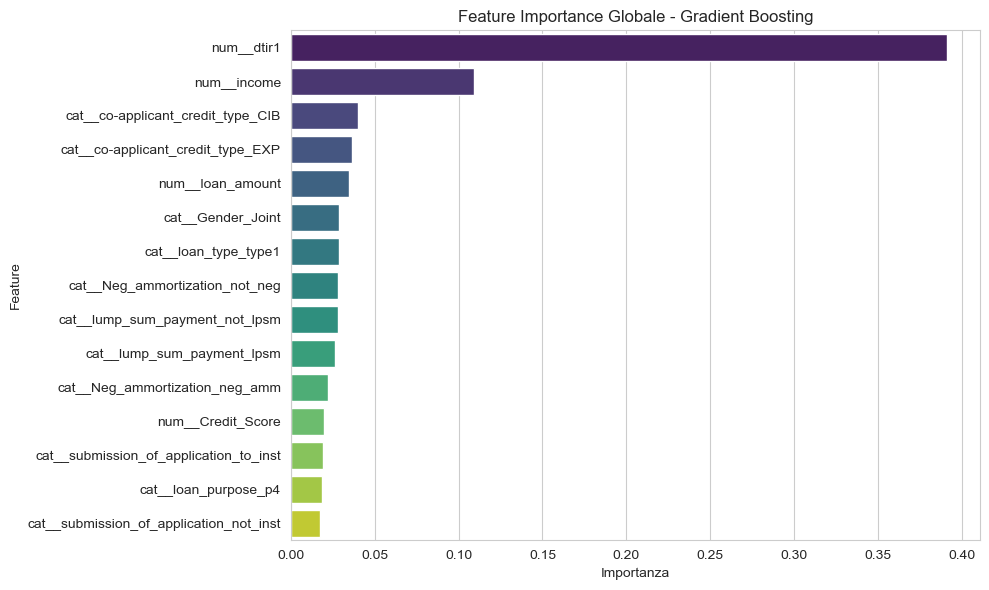

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estraiamo l'importanza nativa
clf = final_model.named_steps["clf"]
importances = clf.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Consideriamo solo le prime 15 per leggibilità se sono troppe
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), palette="viridis")
plt.title('Feature Importance Globale - Gradient Boosting')
plt.xlabel('Importanza')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

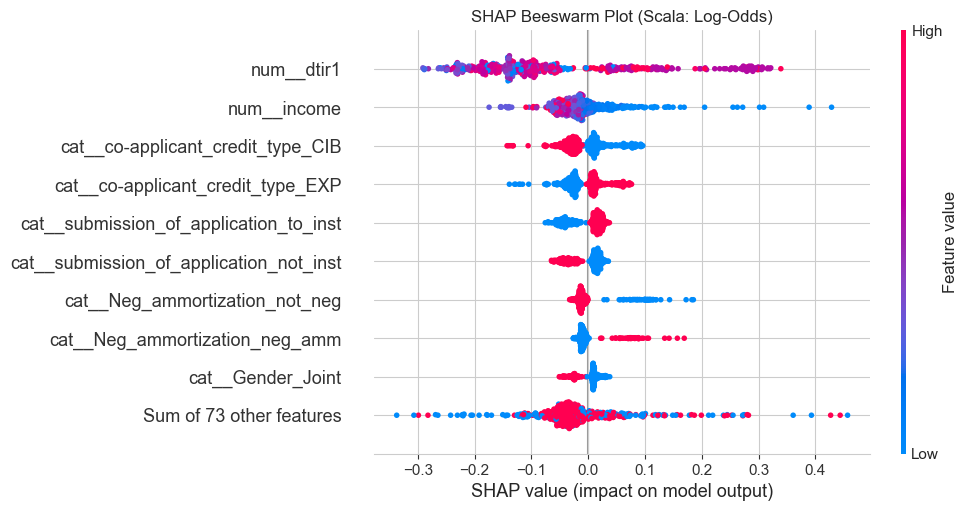

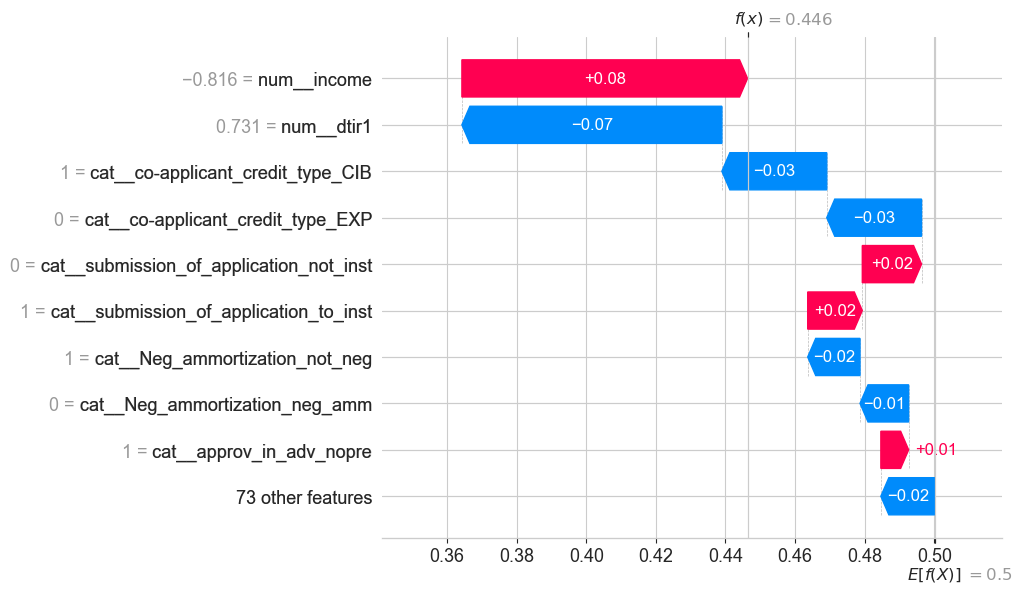

In [114]:
import shap
import matplotlib.pyplot as plt

# 1. Recupera il classificatore interno
clf = best_model.named_steps["clf"]

# 2. Inizializza l'Explainer moderno
explainer = shap.TreeExplainer(clf)
X_subset = X_transformed_df.head(500)

# 3. Usa l'API moderna "Explanation object" chiamando l'explainer
# Per RandomForest binario, questo spesso restituisce un Explanation 3D: (campioni, feature, classi)
shap_values_obj = explainer(X_subset)

# Verifichiamo la forma dell'oggetto. Se l'ultima dimensione è 2, significa che ha le classi (0 e 1).
# Dobbiamo estrarre SOLO la classe 1 (Default) per beeswarm e waterfall.
if len(shap_values_obj.shape) == 3:
    shap_values_class1 = shap_values_obj[:, :, 1]
else:
    # Alcune versioni di SHAP / configurazioni collassano automaticamente per la classe 1
    shap_values_class1 = shap_values_obj


# --- A. SHAP BEESWARM (Direzione e comportamento globale) ---
plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm Plot (Scala: Log-Odds)")
shap.plots.beeswarm(shap_values_class1)
plt.show()

# --- B. SHAP WATERFALL (Spiegazione locale di una singola previsione) ---
plt.figure(figsize=(10, 4))
# Passiamo l'oggetto della classe 1 relativo al primo campione (indice 0)
shap.plots.waterfall(shap_values_class1[0])
plt.show()

In [115]:
from lime import lime_tabular
from IPython.display import display, HTML # <- Import corretto e moderno

# Inizializzazione dell'explainer su dati tabulari (usando la matrice trasformata)
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_transformed,
    feature_names=feature_names,
    class_names=['No Default', 'Default'],
    mode='classification',
    random_state=0
)

# Selezioniamo lo stesso identico cliente visto nel Waterfall (indice 0)
idx_cliente = 0

exp = lime_explainer.explain_instance(
    # .values converte la riga in un array NumPy, eliminando i conflitti di indice
    data_row=X_transformed_df.iloc[idx_cliente].values, 
    predict_fn=clf.predict_proba
)

# Mostra l'output interattivo direttamente nel notebook
print(f"Spiegazione LIME per il cliente all'indice {idx_cliente}:")
html_data = exp.as_html(show_table=True)
display(HTML(html_data))

Spiegazione LIME per il cliente all'indice 0:


In [124]:
import numpy as np
import pandas as pd


y_subset = y.head(500)  # <-- Importante: prendi SOLO le prime 500 etichette
# 1. Calcoliamo le probabilità di default predette dal Random Forest
y_pred_proba = clf.predict_proba(X_subset)[:, 1]

# 2. Definiamo la maschera per i Falsi Negativi (Default Reale = 1, ma Probabilità < 0.5)
soglia_decisionale = 0.5  
is_falso_negativo = (y_subset.values == 1) & (y_pred_proba < soglia_decisionale)

print(f"Analisi basata su {is_falso_negativo.sum()} istanze di Falsi Negativi.")

# 3. Estraiamo i valori SHAP per LA CLASSE 1 SOLO (Default) - riduzione 3D → 2D
shap_values_class1 = shap_values_obj.values[:, :, 1]  # Seleziona solo la classe 1
df_shap_values = pd.DataFrame(shap_values_class1, columns=X_transformed_df.columns)  # Ora è 2D: (500, 82)

# 4. Isoliamo le colonne relative al credit_type
colonne_credit_type = [col for col in df_shap_values.columns if 'dtir1' in col.lower()]

# 5. Calcoliamo le statistiche filtrando SOLO per le righe dei Falsi Negativi
statistiche_fn = []

for col in colonne_credit_type:
    contributi_fn = df_shap_values.loc[is_falso_negativo, col]
    
    statistiche_fn.append({
        "Colonna SHAP (Solo FN)": col,
        "Importanza nei FN (Media |SHAP|)": np.abs(contributi_fn).mean(),
        "Impatto Medio nei FN (Log-Odds)": contributi_fn.mean(),
        "Impatto Massimo nei FN": contributi_fn.max(),
        "Impatto Minimo nei FN": contributi_fn.min()
    })

df_analisi_fn = pd.DataFrame(statistiche_fn).sort_values(by="Importanza nei FN (Media |SHAP|)", ascending=False)

print("\n--- TABELLA SHAP PER CREDIT TYPE (SOLO FALSI NEGATIVI) ---")
display(df_analisi_fn)

Analisi basata su 40 istanze di Falsi Negativi.

--- TABELLA SHAP PER CREDIT TYPE (SOLO FALSI NEGATIVI) ---


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Colonna SHAP (Solo FN),Importanza nei FN (Media |SHAP|),Impatto Medio nei FN (Log-Odds),Impatto Massimo nei FN,Impatto Minimo nei FN
0,num__dtir1,0.11909,-0.107259,0.126496,-0.254297
